In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [2]:
# 1. Memuat User-Item Matrix (Data Training 80%)
# Menggunakan steam_id sebagai index baris
train_matrix = pd.read_csv('user_item_matrix_train.csv', index_col='steam_id')

# PERBAIKAN BUG: Ubah tipe data header kolom dari String kembali ke Integer
train_matrix.columns = train_matrix.columns.astype(int)

# 2. Memuat Data Testing (Ground Truth 20%)
test_df = pd.read_csv('testing_set_groundtruth.csv')

print(f"Dimensi Matriks Pelatihan: {train_matrix.shape[0]} user x {train_matrix.shape[1]} game")
print(f"Total baris Data Pengujian: {test_df.shape[0]} interaksi tersembunyi")

Dimensi Matriks Pelatihan: 492 user x 5227 game
Total baris Data Pengujian: 6514 interaksi tersembunyi


In [3]:
# TAHAP 1: Menghitung Cosine Similarity
# Menghasilkan matriks simetris berukuran (User x User)
cosine_sim_array = cosine_similarity(train_matrix)

# Ubah ke bentuk DataFrame agar mudah dilacak menggunakan steam_id
cosine_sim_df = pd.DataFrame(
    cosine_sim_array, 
    index=train_matrix.index, 
    columns=train_matrix.index
)

# TAHAP 2: Menghitung Euclidean Distance & Mengubahnya menjadi Similarity
euclidean_dist_array = euclidean_distances(train_matrix)

# Transformasi jarak menjadi skor kemiripan (semakin tinggi semakin mirip)
euclidean_sim_array = 1 / (1 + euclidean_dist_array)

# Ubah ke bentuk DataFrame
euclidean_sim_df = pd.DataFrame(
    euclidean_sim_array, 
    index=train_matrix.index, 
    columns=train_matrix.index
)

print("Matriks Kemiripan Pengguna telah berhasil dibentuk!")
print(f"Dimensi Matriks Kemiripan: {cosine_sim_df.shape}")

print("\nContoh 5 baris pertama dari Cosine Similarity Matrix:")
display(cosine_sim_df.head())

print("\nContoh 5 baris pertama dari Euclidean Distance Matrix:")
display(euclidean_sim_df.head())

Matriks Kemiripan Pengguna telah berhasil dibentuk!
Dimensi Matriks Kemiripan: (492, 492)

Contoh 5 baris pertama dari Cosine Similarity Matrix:


steam_id,76561197963033154,76561197963786815,76561197986095555,76561197996826561,76561197999326811,76561198001244067,76561198004857374,76561198005704816,76561198012145612,76561198016531576,...,76561199750485721,76561199750937214,76561199767213080,76561199774736783,76561199796959899,76561199801150324,76561199814528330,76561199837041222,76561199840096740,76561199840738495
steam_id,,,,,,,,,,,,,,,,,,,,,
76561197963033154,1.000000,0.999414,0.611997,0.114473,0.832930,0.663998,0.000008,0.993398,0.882267,0.078349,...,0.999213,0.005082,0.998621,0.998309,0.070527,0.989245,0.394088,0.000000e+00,0.822622,0.995145
76561197963786815,0.999414,1.000000,0.610948,0.114539,0.831898,0.664268,0.000000,0.993961,0.882777,0.078395,...,0.999547,0.000000,0.999164,0.998868,0.070568,0.989817,0.394315,0.000000e+00,0.823097,0.995481
76561197986095555,0.611997,0.610948,1.000000,0.069978,0.708435,0.431521,0.000649,0.607264,0.539846,0.060323,...,0.612537,0.044280,0.610592,0.615153,0.650311,0.604732,0.241146,7.565772e-03,0.785423,0.609557
76561197996826561,0.114473,0.114539,0.069978,1.000000,0.107719,0.076124,0.003807,0.113848,0.110106,0.017994,...,0.114497,0.000000,0.114444,0.114410,0.008083,0.113373,0.054076,3.763773e-01,0.094277,0.115179
76561197999326811,0.832930,0.831898,0.708435,0.107719,1.000000,0.576675,0.000024,0.845346,0.737585,0.223727,...,0.833325,0.046273,0.831238,0.831123,0.058706,0.823774,0.329018,7.244734e-07,0.684809,0.828280



Contoh 5 baris pertama dari Euclidean Distance Matrix:


steam_id,76561197963033154,76561197963786815,76561197986095555,76561197996826561,76561197999326811,76561198001244067,76561198004857374,76561198005704816,76561198012145612,76561198016531576,...,76561199750485721,76561199750937214,76561199767213080,76561199774736783,76561199796959899,76561199801150324,76561199814528330,76561199837041222,76561199840096740,76561199840738495
steam_id,,,,,,,,,,,,,,,,,,,,,
76561197963033154,1.000000,0.966892,0.435830,0.403914,0.600529,0.470445,0.446707,0.896520,0.652206,0.413357,...,0.961810,0.499811,0.950068,0.944994,0.422284,0.871248,0.406795,0.401277,0.591439,0.910023
76561197963786815,0.966892,1.000000,0.435578,0.403978,0.599859,0.470525,0.446800,0.900578,0.652668,0.413427,...,0.970767,0.499924,0.960682,0.954544,0.422359,0.874270,0.406861,0.401340,0.591733,0.912916
76561197986095555,0.435830,0.435578,1.000000,0.337424,0.463824,0.373285,0.358193,0.434690,0.416642,0.343651,...,0.435959,0.379378,0.435492,0.436591,0.445478,0.434075,0.338962,0.336821,0.496138,0.435242
76561197996826561,0.403914,0.403978,0.337424,1.000000,0.383435,0.350202,0.415486,0.403307,0.390538,0.383272,...,0.403930,0.453392,0.403887,0.403854,0.390033,0.402841,0.345685,0.435978,0.380412,0.403631
76561197999326811,0.600529,0.599859,0.463824,0.383435,1.000000,0.439675,0.415562,0.608923,0.541066,0.411613,...,0.600787,0.454302,0.599431,0.599356,0.396565,0.594613,0.384309,0.379650,0.510315,0.597517


In [4]:
def get_top_n_recommendations(target_user, sim_matrix, train_matrix, k=20, n=10):
    """
    Menghasilkan Top-N rekomendasi game untuk target_user.
    
    Parameter:
    - target_user: ID Steam pengguna yang ingin dicarikan rekomendasi
    - sim_matrix: Matriks kemiripan (Cosine atau Euclidean DataFrame)
    - train_matrix: Matriks data latih (User-Item Matrix)
    - k: Jumlah tetangga terdekat (Neighbor Size)
    - n: Jumlah rekomendasi game yang ingin ditampilkan (Top-N)
    """
    
    # 1. Ambil skor kemiripan untuk pengguna target terhadap semua pengguna lain
    user_similarities = sim_matrix.loc[target_user]
    
    # 2. Urutkan dari skor tertinggi, buang diri sendiri, ambil K tetangga terdekat
    # (Diri sendiri dibuang karena kemiripan dengan diri sendiri pasti skornya maksimal)
    nearest_neighbors = user_similarities.drop(target_user).sort_values(ascending=False).head(k)
    
    # 3. Ambil data riwayat bermain dari K tetangga yang terpilih
    neighbors_data = train_matrix.loc[nearest_neighbors.index]
    
    # 4. Hitung Skor Prediksi (Weighted Sum)
    # Rumus: Jumlahkan (Skor Kemiripan Tetangga * Bobot Playtime Tetangga pada game i)
    # Menggunakan dot product matriks agar proses komputasi instan
    predicted_scores = nearest_neighbors.values.dot(neighbors_data.values)
    
    # Jadikan bentuk Pandas Series agar mudah difilter menggunakan app_id
    predicted_scores_series = pd.Series(predicted_scores, index=train_matrix.columns)
    
    # 5. Filter Game yang Sudah Dimainkan
    # Rekomendasi hanya valid untuk game yang poinnya masih 0 di matriks target_user
    target_user_played = train_matrix.loc[target_user]
    games_not_played = target_user_played[target_user_played == 0].index
    
    # Saring prediksi hanya pada game yang belum pernah disentuh pengguna target
    valid_recommendations = predicted_scores_series.loc[games_not_played]
    
    # 6. Urutkan dari skor prediksi tertinggi dan ambil N terbaik
    top_n_recommendations = valid_recommendations.sort_values(ascending=False).head(n)
    
    # Mengembalikan daftar app_id dalam bentuk list
    return top_n_recommendations.index.tolist()

print("Fungsi get_top_n_recommendations berhasil dimuat!")

Fungsi get_top_n_recommendations berhasil dimuat!


In [5]:
# TAHAP 1: Persiapan Ground Truth
# Mengelompokkan data testing (yang disembunyikan) menjadi dictionary
# Format: {steam_id: set(app_id1, app_id2, ...)}
ground_truth_dict = test_df.groupby('steam_id')['app_id'].apply(set).to_dict()

# TAHAP 2: Definisi Variasi Parameter Uji
k_values = [5, 10, 20, 50]
n_values = [5, 10, 15, 20]

# List untuk menampung hasil akhir baris per baris
evaluation_results = []

print("Memulai proses evaluasi massal... Ini akan memakan waktu beberapa menit.\n")

# Looping Skenario Metrik
for metric_name, sim_matrix in [('Cosine', cosine_sim_df), ('Euclidean', euclidean_sim_df)]:
    # Looping variasi K
    for k in k_values:
        # Looping variasi N
        for n in n_values:
            precision_list = []
            recall_list = []
            
            # Evaluasi dihitung untuk setiap user yang ada di ground truth
            for target_user, true_items in ground_truth_dict.items():
                # Pencegahan error jika user tidak ada di matriks training
                if target_user not in train_matrix.index:
                    continue
                
                # Eksekusi mesin rekomendasi
                recommended_items = get_top_n_recommendations(
                    target_user=target_user, 
                    sim_matrix=sim_matrix, 
                    train_matrix=train_matrix, 
                    k=k, 
                    n=n
                )
                
                recommended_set = set(recommended_items)
                
                # Hitung Irisan (Berapa banyak tebakan yang benar/relevan)
                hits = len(recommended_set.intersection(true_items))
                
                # Hitung Rumus Evaluasi
                precision = hits / n if n > 0 else 0
                recall = hits / len(true_items) if len(true_items) > 0 else 0
                
                precision_list.append(precision)
                recall_list.append(recall)
            
            # Menghitung nilai rata-rata dari seluruh user untuk kombinasi saat ini
            avg_precision = np.mean(precision_list)
            avg_recall = np.mean(recall_list)
            
            # Menyimpan data ke dalam struktur tabel
            evaluation_results.append({
                'Metrik Jarak': metric_name,
                'K (Neighbors)': k,
                'N (Top-N)': n,
                'Precision@N': round(avg_precision, 4),
                'Recall@N': round(avg_recall, 4)
            })
            print(f"Selesai: {metric_name} | K = {k:2} | N = {n:2}")

# TAHAP 3: Konversi ke DataFrame dan Tampilkan Hasil
df_results = pd.DataFrame(evaluation_results)

print("\n" + "="*50)
print("=== TABEL HASIL EVALUASI KOMPARATIF (BAB IV) ===")
print("="*50)
display(df_results)

# Simpan ke CSV agar angkanya tidak hilang dan mudah disalin ke Microsoft Word
df_results.to_csv('hasil_evaluasi_skripsi.csv', index=False)
print("\n[SUKSES] Data telah diekspor ke 'hasil_evaluasi_skripsi.csv'")

Memulai proses evaluasi massal... Ini akan memakan waktu beberapa menit.

Selesai: Cosine | K =  5 | N =  5
Selesai: Cosine | K =  5 | N = 10
Selesai: Cosine | K =  5 | N = 15
Selesai: Cosine | K =  5 | N = 20
Selesai: Cosine | K = 10 | N =  5
Selesai: Cosine | K = 10 | N = 10
Selesai: Cosine | K = 10 | N = 15
Selesai: Cosine | K = 10 | N = 20
Selesai: Cosine | K = 20 | N =  5
Selesai: Cosine | K = 20 | N = 10
Selesai: Cosine | K = 20 | N = 15
Selesai: Cosine | K = 20 | N = 20
Selesai: Cosine | K = 50 | N =  5
Selesai: Cosine | K = 50 | N = 10
Selesai: Cosine | K = 50 | N = 15
Selesai: Cosine | K = 50 | N = 20
Selesai: Euclidean | K =  5 | N =  5
Selesai: Euclidean | K =  5 | N = 10
Selesai: Euclidean | K =  5 | N = 15
Selesai: Euclidean | K =  5 | N = 20
Selesai: Euclidean | K = 10 | N =  5
Selesai: Euclidean | K = 10 | N = 10
Selesai: Euclidean | K = 10 | N = 15
Selesai: Euclidean | K = 10 | N = 20
Selesai: Euclidean | K = 20 | N =  5
Selesai: Euclidean | K = 20 | N = 10
Selesai: Euc

,Metrik Jarak,K (Neighbors),N (Top-N),Precision@N,Recall@N
0,Cosine,5,5,0.0902,0.0612
1,Cosine,5,10,0.0744,0.0941
2,Cosine,5,15,0.0650,0.1217
3,Cosine,5,20,0.0570,0.1388
4,Cosine,10,5,0.1053,0.0669
5,Cosine,10,10,0.0846,0.1046
6,Cosine,10,15,0.0741,0.1359
7,Cosine,10,20,0.0675,0.1606
8,Cosine,20,5,0.1187,0.0715
9,Cosine,20,10,0.0941,0.1081



[SUKSES] Data telah diekspor ke 'hasil_evaluasi_skripsi.csv'


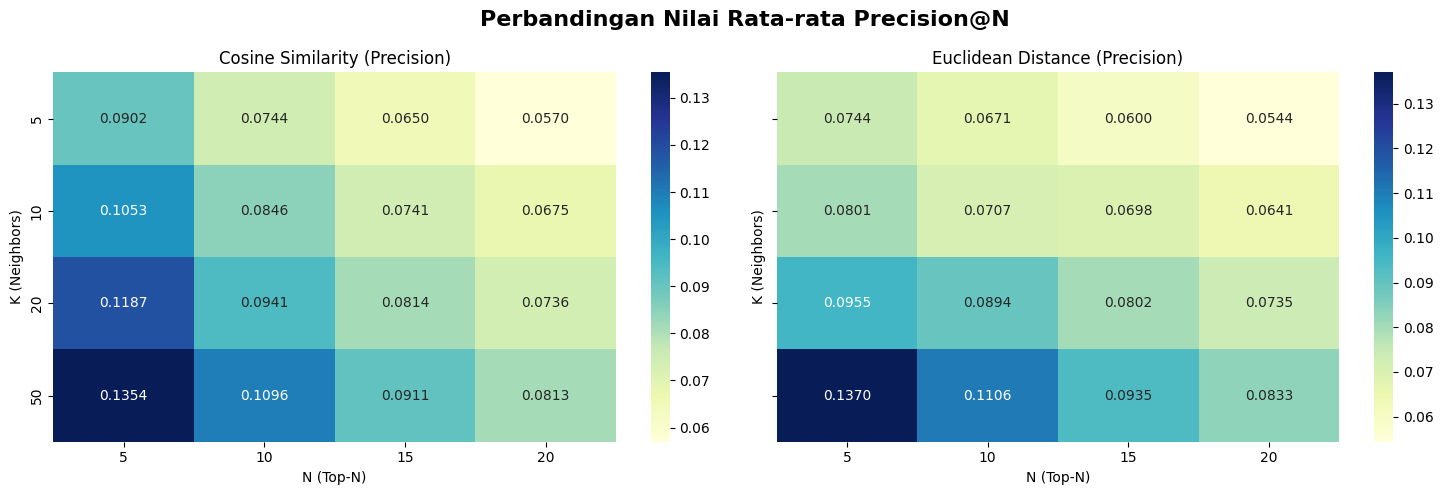

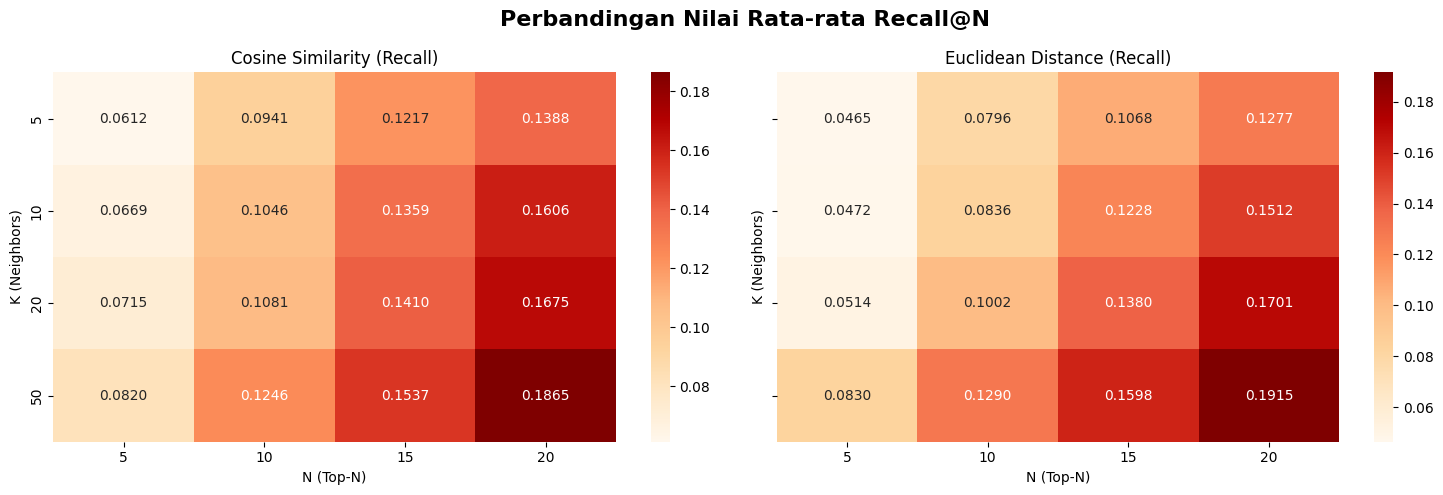

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil data hasil evaluasi terbaru
df_eval = pd.read_csv('hasil_evaluasi_skripsi.csv')

# 2. Pisahkan data berdasarkan metrik jarak
df_cosine = df_eval[df_eval['Metrik Jarak'] == 'Cosine']
df_euclidean = df_eval[df_eval['Metrik Jarak'] == 'Euclidean']

# 3. Pivot data agar membentuk matriks (K x N) untuk keperluan Heatmap
# Heatmap Precision
cosine_prec_pivot = df_cosine.pivot(index='K (Neighbors)', columns='N (Top-N)', values='Precision@N')
eucl_prec_pivot = df_euclidean.pivot(index='K (Neighbors)', columns='N (Top-N)', values='Precision@N')

# Heatmap Recall
cosine_rec_pivot = df_cosine.pivot(index='K (Neighbors)', columns='N (Top-N)', values='Recall@N')
eucl_rec_pivot = df_euclidean.pivot(index='K (Neighbors)', columns='N (Top-N)', values='Recall@N')

# 4. SETTING GAMBAR 1: HEATMAP PRECISION COMPARSION
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('Perbandingan Nilai Rata-rata Precision@N', fontsize=16, fontweight='bold')

sns.heatmap(cosine_prec_pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title('Cosine Similarity (Precision)')

sns.heatmap(eucl_prec_pivot, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title('Euclidean Distance (Precision)')

plt.tight_layout()
plt.savefig('heatmap_precision_skripsi.png', dpi=300) # Auto-save buat dipindah ke Word
plt.show()

# 5. SETTING GAMBAR 2: HEATMAP RECALL COMPARISON
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('Perbandingan Nilai Rata-rata Recall@N', fontsize=16, fontweight='bold')

sns.heatmap(cosine_rec_pivot, annot=True, fmt=".4f", cmap="OrRd", ax=axes[0])
axes[0].set_title('Cosine Similarity (Recall)')

sns.heatmap(eucl_rec_pivot, annot=True, fmt=".4f", cmap="OrRd", ax=axes[1])
axes[1].set_title('Euclidean Distance (Recall)')

plt.tight_layout()
plt.savefig('heatmap_recall_skripsi.png', dpi=300) # Auto-save buat dipindah ke Word
plt.show()

In [6]:
import json

# 1. Pastikan kamus game_mapping sudah dimuat
with open('game_mapping.json', 'r', encoding='utf-8') as f:
    game_mapping = json.load(f)

# ID target yang ingin diuji
target_id = 76561199090195496

print(f"=== HASIL UJI COBA LIVE BACKEND ===")
print(f"Menguji Steam ID: {target_id}")

# 2. Validasi apakah ID ini ada di dalam data pelatihan
if target_id in train_matrix.index:
    
    # 3. Ambil data riwayat bermain user tersebut
    user_history = train_matrix.loc[target_id]
    played_game_ids = user_history[user_history > 0].index.tolist()
    
    print("\n--> Beberapa Game yang Ada di Library User Ini (Data Latih):")
    # Tampilkan maksimal 5 game pertama untuk melihat kecenderungan seleranya
    for app_id in played_game_ids[:5]:
        game_name = game_mapping.get(str(app_id), f"Unknown Game (ID: {app_id})")
        print(f"    - {game_name}")
        
    print("\n" + "-"*40)
    
    # 4. Ambil rekomendasi menggunakan parameter terbaik (Cosine, K=50, N=10)
    recommended_game_ids = get_top_n_recommendations(
        target_user=target_id,
        sim_matrix=cosine_sim_df,
        train_matrix=train_matrix,
        k=50,
        n=10
    )
    
    # 5. Tampilkan hasil rekomendasi yang sudah diterjemahkan
    print(f"--> TOP-10 REKOMENDASI GAME UNTUK USER INI:")
    if recommended_game_ids:
        for i, app_id in enumerate(recommended_game_ids, 1):
            game_name = game_mapping.get(str(app_id), f"Unknown Game (ID: {app_id})")
            print(f"    {i}. {game_name} (App ID: {app_id})")
    else:
        print("    Tidak ada rekomendasi yang dapat dihasilkan untuk user ini.")
        
else:
    print(f"\n[PERINGATAN] ID {target_id} tidak ditemukan di dalam data pelatihan.")
    print("Kemungkinan ID ini tereliminasi di tahap 'Re-Validation' karena jumlah game validnya di bawah 10 setelah filter kata kunci.")

=== HASIL UJI COBA LIVE BACKEND ===
Menguji Steam ID: 76561199090195496

--> Beberapa Game yang Ada di Library User Ini (Data Latih):
    - Counter-Strike 2
    - The Witcher 2: Assassins of Kings Enhanced Edition
    - Terraria
    - Don't Starve
    - Just Cause 3

----------------------------------------
--> TOP-10 REKOMENDASI GAME UNTUK USER INI:
    1. Grand Theft Auto V Legacy (App ID: 271590)
    2. Rust (App ID: 252490)
    3. Garry's Mod (App ID: 4000)
    4. Euro Truck Simulator 2 (App ID: 227300)
    5. The Forest (App ID: 242760)
    6. Valheim (App ID: 892970)
    7. Phasmophobia (App ID: 739630)
    8. R.E.P.O. (App ID: 3241660)
    9. Mount & Blade II: Bannerlord (App ID: 261550)
    10. FOR HONOR (App ID: 304390)
